In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import joblib

In [2]:
try:
    medicine_source_df = feature_df.copy()
    print("Using feature-engineered data from notebook memory")

except NameError:
    medicine_source_df = pd.read_excel(
        "clinical_feature_engineered_data.xlsx",
        sheet_name="Feature_Engineered_Data"
    )
    print("Using saved feature-engineered dataset")

print("Dataset shape:", medicine_source_df.shape)
medicine_source_df.head()

Using saved feature-engineered dataset
Dataset shape: (500, 31)


,patient_id,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,...,bp_age_interaction,allergy_recorded_flag,family_history_flag,adherence_score,glucose_mg_dl_dataset_zscore,systolic_bp_mmhg_dataset_zscore,diastolic_bp_mmhg_dataset_zscore,cholesterol_mg_dl_dataset_zscore,heart_rate_bpm_dataset_zscore,measurement_deviation_score
0,SYN-0001,28,Female,Seasonal Allergy,97,132,85,214,73,None recorded,...,3696,0,0,2,-0.324226,0.254356,0.339338,0.424061,-0.315852,0.331566
1,SYN-0002,80,Female,Acid Reflux,80,123,79,189,59,None recorded,...,9840,0,1,1,-0.809337,-0.237734,-0.210049,-0.216205,-1.546215,0.603908
2,SYN-0003,36,Female,Asthma,86,121,66,192,82,None recorded,...,4356,0,0,1,-0.638121,-0.347087,-1.400387,-0.139373,0.475096,0.600013
3,SYN-0004,21,Male,High Cholesterol,103,120,69,278,85,None recorded,...,2520,0,1,2,-0.153010,-0.401764,-1.125693,2.063142,0.738745,0.896471
4,SYN-0005,58,Male,High Cholesterol,79,111,76,244,64,None recorded,...,6438,0,1,2,-0.837873,-0.893854,-0.484742,1.192380,-1.106799,0.903130


In [3]:
medicine_source_df.columns = (
    medicine_source_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(medicine_source_df.columns.tolist())

['patient_id', 'age_years', 'sex', 'condition', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'recorded_allergy', 'family_history', 'adherence_level', 'historical_medication_class', 'recorded_outcome', 'data_quality_status', 'age_group', 'pulse_pressure_mmhg', 'systolic_diastolic_ratio', 'glucose_cholesterol_interaction', 'glucose_age_interaction', 'cholesterol_age_interaction', 'bp_age_interaction', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score', 'glucose_mg_dl_dataset_zscore', 'systolic_bp_mmhg_dataset_zscore', 'diastolic_bp_mmhg_dataset_zscore', 'cholesterol_mg_dl_dataset_zscore', 'heart_rate_bpm_dataset_zscore', 'measurement_deviation_score']


In [4]:
required_columns = [
    "historical_medication_class",
    "condition",
    "age_years",
    "sex",
    "glucose_mg_dl",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "cholesterol_mg_dl",
    "heart_rate_bpm",
    "recorded_allergy",
    "adherence_level",
    "recorded_outcome"
]

missing_columns = [
    column for column in required_columns
    if column not in medicine_source_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required medicine-profile columns are available.")

All required medicine-profile columns are available.


In [5]:
medicine_class_counts = (
    medicine_source_df[
        "historical_medication_class"
    ]
    .value_counts()
    .reset_index()
)

medicine_class_counts.columns = [
    "medicine_class",
    "historical_record_count"
]

print(
    "Number of medication classes:",
    medicine_class_counts["medicine_class"].nunique()
)

medicine_class_counts

Number of medication classes: 12


,medicine_class,historical_record_count
0,Antihistamine class A,52
1,Controller inhaler class,47
2,Antidiabetic class A,45
3,Antihypertensive class A,43
4,Lipid-lowering class A,42
5,Acid-suppression class A,42
6,Antidiabetic class B,42
7,Antihypertensive class B,42
8,Antihistamine class B,40
9,Bronchodilator class,36


In [6]:
medicine_classes = (
    medicine_source_df[
        ["historical_medication_class"]
    ]
    .drop_duplicates()
    .sort_values("historical_medication_class")
    .reset_index(drop=True)
)

medicine_classes.insert(
    0,
    "medicine_class_id",
    [
        f"MEDC-{number:03d}"
        for number in range(
            1,
            len(medicine_classes) + 1
        )
    ]
)

medicine_classes

,medicine_class_id,historical_medication_class
0,MEDC-001,Acid-suppression class A
1,MEDC-002,Acid-suppression class B
2,MEDC-003,Antidiabetic class A
3,MEDC-004,Antidiabetic class B
4,MEDC-005,Antihistamine class A
5,MEDC-006,Antihistamine class B
6,MEDC-007,Antihypertensive class A
7,MEDC-008,Antihypertensive class B
8,MEDC-009,Bronchodilator class
9,MEDC-010,Controller inhaler class


In [7]:
medicine_records = medicine_source_df.merge(
    medicine_classes,
    on="historical_medication_class",
    how="left",
    validate="many_to_one"
)

print("Medicine records shape:", medicine_records.shape)
print(
    "Missing medicine IDs:",
    medicine_records["medicine_class_id"].isnull().sum()
)

medicine_records[
    [
        "patient_id",
        "medicine_class_id",
        "historical_medication_class"
    ]
].head()

Medicine records shape: (500, 32)
Missing medicine IDs: 0


,patient_id,medicine_class_id,historical_medication_class
0,SYN-0001,MEDC-005,Antihistamine class A
1,SYN-0002,MEDC-001,Acid-suppression class A
2,SYN-0003,MEDC-010,Controller inhaler class
3,SYN-0004,MEDC-012,Lipid-lowering class B
4,SYN-0005,MEDC-012,Lipid-lowering class B


In [8]:
numeric_columns = [
    "age_years",
    "glucose_mg_dl",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "cholesterol_mg_dl",
    "heart_rate_bpm"
]

medicine_numeric_profile = (
    medicine_records
    .groupby(
        [
            "medicine_class_id",
            "historical_medication_class"
        ]
    )[numeric_columns]
    .mean()
    .round(4)
    .reset_index()
)

medicine_numeric_profile = medicine_numeric_profile.rename(
    columns={
        column: f"mean_{column}"
        for column in numeric_columns
    }
)

medicine_numeric_profile.head()

,medicine_class_id,historical_medication_class,mean_age_years,mean_glucose_mg_dl,mean_systolic_bp_mmhg,mean_diastolic_bp_mmhg,mean_cholesterol_mg_dl,mean_heart_rate_bpm
0,MEDC-001,Acid-suppression class A,47.0238,92.5000,120.7857,79.0000,185.8571,75.5714
1,MEDC-002,Acid-suppression class B,47.9714,93.3143,120.1143,77.1143,188.1143,77.8857
2,MEDC-003,Antidiabetic class A,46.8889,175.0222,121.0000,78.1778,182.1333,76.1111
3,MEDC-004,Antidiabetic class B,49.8333,174.6667,120.6667,77.4762,181.1429,77.4286
4,MEDC-005,Antihistamine class A,43.7692,96.8462,121.8654,79.2500,180.6731,76.6154


In [9]:
medicine_usage_profile = (
    medicine_records
    .groupby(
        [
            "medicine_class_id",
            "historical_medication_class"
        ]
    )
    .size()
    .reset_index(name="historical_record_count")
)

medicine_usage_profile[
    "historical_record_percentage"
] = (
    medicine_usage_profile["historical_record_count"]
    / len(medicine_records)
    * 100
).round(2)

medicine_usage_profile

,medicine_class_id,historical_medication_class,historical_record_count,historical_record_percentage
0,MEDC-001,Acid-suppression class A,42,8.4
1,MEDC-002,Acid-suppression class B,35,7.0
2,MEDC-003,Antidiabetic class A,45,9.0
3,MEDC-004,Antidiabetic class B,42,8.4
4,MEDC-005,Antihistamine class A,52,10.4
5,MEDC-006,Antihistamine class B,40,8.0
6,MEDC-007,Antihypertensive class A,43,8.6
7,MEDC-008,Antihypertensive class B,42,8.4
8,MEDC-009,Bronchodilator class,36,7.2
9,MEDC-010,Controller inhaler class,47,9.4


In [10]:
def create_distribution_profile(
    dataframe,
    category_column,
    prefix
):
    distribution = pd.crosstab(
        [
            dataframe["medicine_class_id"],
            dataframe["historical_medication_class"]
        ],
        dataframe[category_column],
        normalize="index"
    )

    distribution.columns = [
        f"{prefix}_{str(column).lower().replace(' ', '_').replace('-', '_')}"
        for column in distribution.columns
    ]

    return distribution.reset_index()

In [11]:
medicine_condition_profile = (
    create_distribution_profile(
        medicine_records,
        category_column="condition",
        prefix="condition_share"
    )
)

medicine_condition_profile.head()

,medicine_class_id,historical_medication_class,condition_share_acid_reflux,condition_share_asthma,condition_share_high_cholesterol,condition_share_hypertension,condition_share_seasonal_allergy,condition_share_type_2_diabetes
0,MEDC-001,Acid-suppression class A,1.0,0.0,0.0,0.0,0.0,0.0
1,MEDC-002,Acid-suppression class B,1.0,0.0,0.0,0.0,0.0,0.0
2,MEDC-003,Antidiabetic class A,0.0,0.0,0.0,0.0,0.0,1.0
3,MEDC-004,Antidiabetic class B,0.0,0.0,0.0,0.0,0.0,1.0
4,MEDC-005,Antihistamine class A,0.0,0.0,0.0,0.0,1.0,0.0


In [12]:
medicine_outcome_profile = (
    create_distribution_profile(
        medicine_records,
        category_column="recorded_outcome",
        prefix="outcome_share"
    )
)

medicine_outcome_profile.head()

,medicine_class_id,historical_medication_class,outcome_share_follow_up_required,outcome_share_improved,outcome_share_stable
0,MEDC-001,Acid-suppression class A,0.357143,0.357143,0.285714
1,MEDC-002,Acid-suppression class B,0.400000,0.400000,0.200000
2,MEDC-003,Antidiabetic class A,0.333333,0.377778,0.288889
3,MEDC-004,Antidiabetic class B,0.285714,0.333333,0.380952
4,MEDC-005,Antihistamine class A,0.230769,0.288462,0.480769


In [13]:
medicine_adherence_profile = (
    create_distribution_profile(
        medicine_records,
        category_column="adherence_level",
        prefix="adherence_share"
    )
)

medicine_adherence_profile.head()

,medicine_class_id,historical_medication_class,adherence_share_high,adherence_share_low,adherence_share_medium
0,MEDC-001,Acid-suppression class A,0.333333,0.238095,0.428571
1,MEDC-002,Acid-suppression class B,0.400000,0.342857,0.257143
2,MEDC-003,Antidiabetic class A,0.444444,0.177778,0.377778
3,MEDC-004,Antidiabetic class B,0.333333,0.309524,0.357143
4,MEDC-005,Antihistamine class A,0.423077,0.288462,0.288462


In [14]:
medicine_sex_profile = (
    create_distribution_profile(
        medicine_records,
        category_column="sex",
        prefix="sex_share"
    )
)

medicine_sex_profile.head()

,medicine_class_id,historical_medication_class,sex_share_female,sex_share_male
0,MEDC-001,Acid-suppression class A,0.642857,0.357143
1,MEDC-002,Acid-suppression class B,0.400000,0.600000
2,MEDC-003,Antidiabetic class A,0.400000,0.600000
3,MEDC-004,Antidiabetic class B,0.476190,0.523810
4,MEDC-005,Antihistamine class A,0.557692,0.442308


In [15]:
medicine_allergy_profile = (
    create_distribution_profile(
        medicine_records,
        category_column="recorded_allergy",
        prefix="allergy_share"
    )
)

medicine_allergy_profile.head()

,medicine_class_id,historical_medication_class,allergy_share_latex,allergy_share_nsaid,allergy_share_none_recorded,allergy_share_penicillin,allergy_share_sulfonamide
0,MEDC-001,Acid-suppression class A,0.047619,0.047619,0.785714,0.047619,0.071429
1,MEDC-002,Acid-suppression class B,0.057143,0.000000,0.857143,0.057143,0.028571
2,MEDC-003,Antidiabetic class A,0.022222,0.088889,0.777778,0.066667,0.044444
3,MEDC-004,Antidiabetic class B,0.047619,0.095238,0.785714,0.047619,0.023810
4,MEDC-005,Antihistamine class A,0.115385,0.057692,0.769231,0.019231,0.038462


In [16]:
medicine_profile = medicine_usage_profile.copy()

profile_tables = [
    medicine_numeric_profile,
    medicine_condition_profile,
    medicine_outcome_profile,
    medicine_adherence_profile,
    medicine_sex_profile,
    medicine_allergy_profile
]

for profile_table in profile_tables:
    medicine_profile = medicine_profile.merge(
        profile_table,
        on=[
            "medicine_class_id",
            "historical_medication_class"
        ],
        how="left",
        validate="one_to_one"
    )

print("Medicine profile shape:", medicine_profile.shape)
medicine_profile.head()

Medicine profile shape: (12, 29)


,medicine_class_id,historical_medication_class,historical_record_count,historical_record_percentage,mean_age_years,mean_glucose_mg_dl,mean_systolic_bp_mmhg,mean_diastolic_bp_mmhg,mean_cholesterol_mg_dl,mean_heart_rate_bpm,...,adherence_share_high,adherence_share_low,adherence_share_medium,sex_share_female,sex_share_male,allergy_share_latex,allergy_share_nsaid,allergy_share_none_recorded,allergy_share_penicillin,allergy_share_sulfonamide
0,MEDC-001,Acid-suppression class A,42,8.4,47.0238,92.5000,120.7857,79.0000,185.8571,75.5714,...,0.333333,0.238095,0.428571,0.642857,0.357143,0.047619,0.047619,0.785714,0.047619,0.071429
1,MEDC-002,Acid-suppression class B,35,7.0,47.9714,93.3143,120.1143,77.1143,188.1143,77.8857,...,0.400000,0.342857,0.257143,0.400000,0.600000,0.057143,0.000000,0.857143,0.057143,0.028571
2,MEDC-003,Antidiabetic class A,45,9.0,46.8889,175.0222,121.0000,78.1778,182.1333,76.1111,...,0.444444,0.177778,0.377778,0.400000,0.600000,0.022222,0.088889,0.777778,0.066667,0.044444
3,MEDC-004,Antidiabetic class B,42,8.4,49.8333,174.6667,120.6667,77.4762,181.1429,77.4286,...,0.333333,0.309524,0.357143,0.476190,0.523810,0.047619,0.095238,0.785714,0.047619,0.023810
4,MEDC-005,Antihistamine class A,52,10.4,43.7692,96.8462,121.8654,79.2500,180.6731,76.6154,...,0.423077,0.288462,0.288462,0.557692,0.442308,0.115385,0.057692,0.769231,0.019231,0.038462


In [17]:
medicine_profile_quality = pd.DataFrame({
    "check": [
        "Total medicine classes",
        "Unique medicine-class IDs",
        "Duplicate medicine-class IDs",
        "Missing profile values"
    ],
    "result": [
        len(medicine_profile),
        medicine_profile[
            "medicine_class_id"
        ].nunique(),
        medicine_profile[
            "medicine_class_id"
        ].duplicated().sum(),
        medicine_profile.isnull().sum().sum()
    ]
})

medicine_profile_quality

,check,result
0,Total medicine classes,12
1,Unique medicine-class IDs,12
2,Duplicate medicine-class IDs,0
3,Missing profile values,0


In [18]:
medicine_metadata = medicine_profile[
    [
        "medicine_class_id",
        "historical_medication_class"
    ]
].copy()

medicine_vector_features = medicine_profile.drop(
    columns=[
        "medicine_class_id",
        "historical_medication_class"
    ]
).copy()

print(
    "Medicine vector feature count:",
    medicine_vector_features.shape[1]
)

Medicine vector feature count: 27


In [19]:
medicine_scaler = StandardScaler()

medicine_vectors = medicine_scaler.fit_transform(
    medicine_vector_features
)

print("Medicine vector shape:", medicine_vectors.shape)

Medicine vector shape: (12, 27)


In [20]:
medicine_vector_df = pd.DataFrame(
    medicine_vectors,
    columns=medicine_vector_features.columns
)

medicine_vector_df.insert(
    0,
    "historical_medication_class",
    medicine_metadata[
        "historical_medication_class"
    ].values
)

medicine_vector_df.insert(
    0,
    "medicine_class_id",
    medicine_metadata["medicine_class_id"].values
)

medicine_vector_df.head()

,medicine_class_id,historical_medication_class,historical_record_count,historical_record_percentage,mean_age_years,mean_glucose_mg_dl,mean_systolic_bp_mmhg,mean_diastolic_bp_mmhg,mean_cholesterol_mg_dl,mean_heart_rate_bpm,...,adherence_share_high,adherence_share_low,adherence_share_medium,sex_share_female,sex_share_male,allergy_share_latex,allergy_share_nsaid,allergy_share_none_recorded,allergy_share_penicillin,allergy_share_sulfonamide
0,MEDC-001,Acid-suppression class A,0.068199,0.068199,-0.298366,-0.508764,-0.453018,-0.288471,-0.414138,-0.766556,...,-0.334647,-1.196313,1.444307,1.849104,-1.849104,0.001353,0.188412,0.037379,-0.547052,0.097313
1,MEDC-002,Acid-suppression class B,-1.363989,-1.363989,0.079386,-0.481657,-0.500380,-0.537723,-0.341273,0.901663,...,0.819983,0.587475,-1.319606,-1.049406,1.049406,0.334690,-1.468070,1.974287,-0.016354,-1.300378
2,MEDC-003,Antidiabetic class A,0.681994,0.681994,-0.352143,2.238299,-0.437901,-0.397149,-0.534346,-0.377523,...,1.589737,-2.223343,0.625370,-1.049406,1.049406,-0.887545,1.624030,-0.177833,0.514345,-0.782715
3,MEDC-004,Antidiabetic class B,0.068199,0.068199,0.821617,2.226465,-0.461412,-0.489887,-0.566317,0.572171,...,-0.334647,0.019906,0.292677,-0.140069,0.140069,0.001353,1.844894,0.037379,-0.547052,-1.455678
4,MEDC-005,Antihistamine class A,2.114182,2.114182,-1.595785,-0.364084,-0.376855,-0.255426,-0.581482,-0.014008,...,1.219663,-0.338722,-0.814660,0.832658,-0.832658,2.373172,0.538822,-0.409600,-2.128941,-0.977834


In [21]:
medicine_pca = PCA(
    n_components=0.95,
    random_state=42
)

reduced_medicine_vectors = (
    medicine_pca.fit_transform(medicine_vectors)
)

print("Original dimensions:", medicine_vectors.shape[1])
print("Reduced dimensions:", reduced_medicine_vectors.shape[1])

print(
    "Explained variation:",
    round(
        medicine_pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

Original dimensions: 27
Reduced dimensions: 8
Explained variation: 95.88 %


In [22]:
component_names = [
    f"medicine_component_{number}"
    for number in range(
        1,
        reduced_medicine_vectors.shape[1] + 1
    )
]

reduced_medicine_profile_df = pd.DataFrame(
    reduced_medicine_vectors,
    columns=component_names
)

reduced_medicine_profile_df.insert(
    0,
    "historical_medication_class",
    medicine_metadata[
        "historical_medication_class"
    ].values
)

reduced_medicine_profile_df.insert(
    0,
    "medicine_class_id",
    medicine_metadata[
        "medicine_class_id"
    ].values
)

reduced_medicine_profile_df.head()

,medicine_class_id,historical_medication_class,medicine_component_1,medicine_component_2,medicine_component_3,medicine_component_4,medicine_component_5,medicine_component_6,medicine_component_7,medicine_component_8
0,MEDC-001,Acid-suppression class A,1.262288,-0.302488,0.657964,2.503073,1.014467,-1.778398,0.963078,1.623037
1,MEDC-002,Acid-suppression class B,-3.181040,-1.027132,-1.295531,0.448897,2.291634,-1.316081,2.091072,-1.719707
2,MEDC-003,Antidiabetic class A,0.596628,-2.900008,2.840121,-2.502175,-0.371358,-1.632337,-1.007951,-0.584465
3,MEDC-004,Antidiabetic class B,0.578782,-2.602941,1.919932,-1.915170,-1.099159,0.796909,1.534560,0.818125
4,MEDC-005,Antihistamine class A,4.690352,-2.495584,-2.162321,0.772388,0.040041,1.935359,-0.462782,-1.427951


In [23]:
medicine_similarity_matrix = cosine_similarity(
    medicine_vectors
)

medicine_similarity_df = pd.DataFrame(
    medicine_similarity_matrix,
    index=medicine_metadata[
        "historical_medication_class"
    ],
    columns=medicine_metadata[
        "historical_medication_class"
    ]
)

medicine_similarity_df.round(3)

historical_medication_class,Acid-suppression class A,Acid-suppression class B,Antidiabetic class A,Antidiabetic class B,Antihistamine class A,Antihistamine class B,Antihypertensive class A,Antihypertensive class B,Bronchodilator class,Controller inhaler class,Lipid-lowering class A,Lipid-lowering class B
historical_medication_class,,,,,,,,,,,,
Acid-suppression class A,1.000,-0.013,-0.087,-0.125,0.075,0.144,-0.105,0.015,-0.534,-0.087,0.133,-0.233
Acid-suppression class B,-0.013,1.000,-0.132,-0.172,-0.313,0.007,-0.349,-0.410,0.262,0.106,-0.138,0.193
Antidiabetic class A,-0.087,-0.132,1.000,0.629,0.001,-0.164,-0.379,-0.164,-0.259,-0.050,-0.183,-0.130
Antidiabetic class B,-0.125,-0.172,0.629,1.000,0.105,-0.123,-0.229,-0.371,-0.018,-0.370,0.007,-0.254
Antihistamine class A,0.075,-0.313,0.001,0.105,1.000,0.338,0.065,-0.163,-0.389,-0.155,-0.227,-0.452
Antihistamine class B,0.144,0.007,-0.164,-0.123,0.338,1.000,-0.228,-0.255,-0.057,-0.271,-0.414,0.071
Antihypertensive class A,-0.105,-0.349,-0.379,-0.229,0.065,-0.228,1.000,0.662,-0.052,-0.023,-0.125,-0.339
Antihypertensive class B,0.015,-0.410,-0.164,-0.371,-0.163,-0.255,0.662,1.000,-0.236,0.021,-0.027,-0.124
Bronchodilator class,-0.534,0.262,-0.259,-0.018,-0.389,-0.057,-0.052,-0.236,1.000,0.110,-0.234,0.350


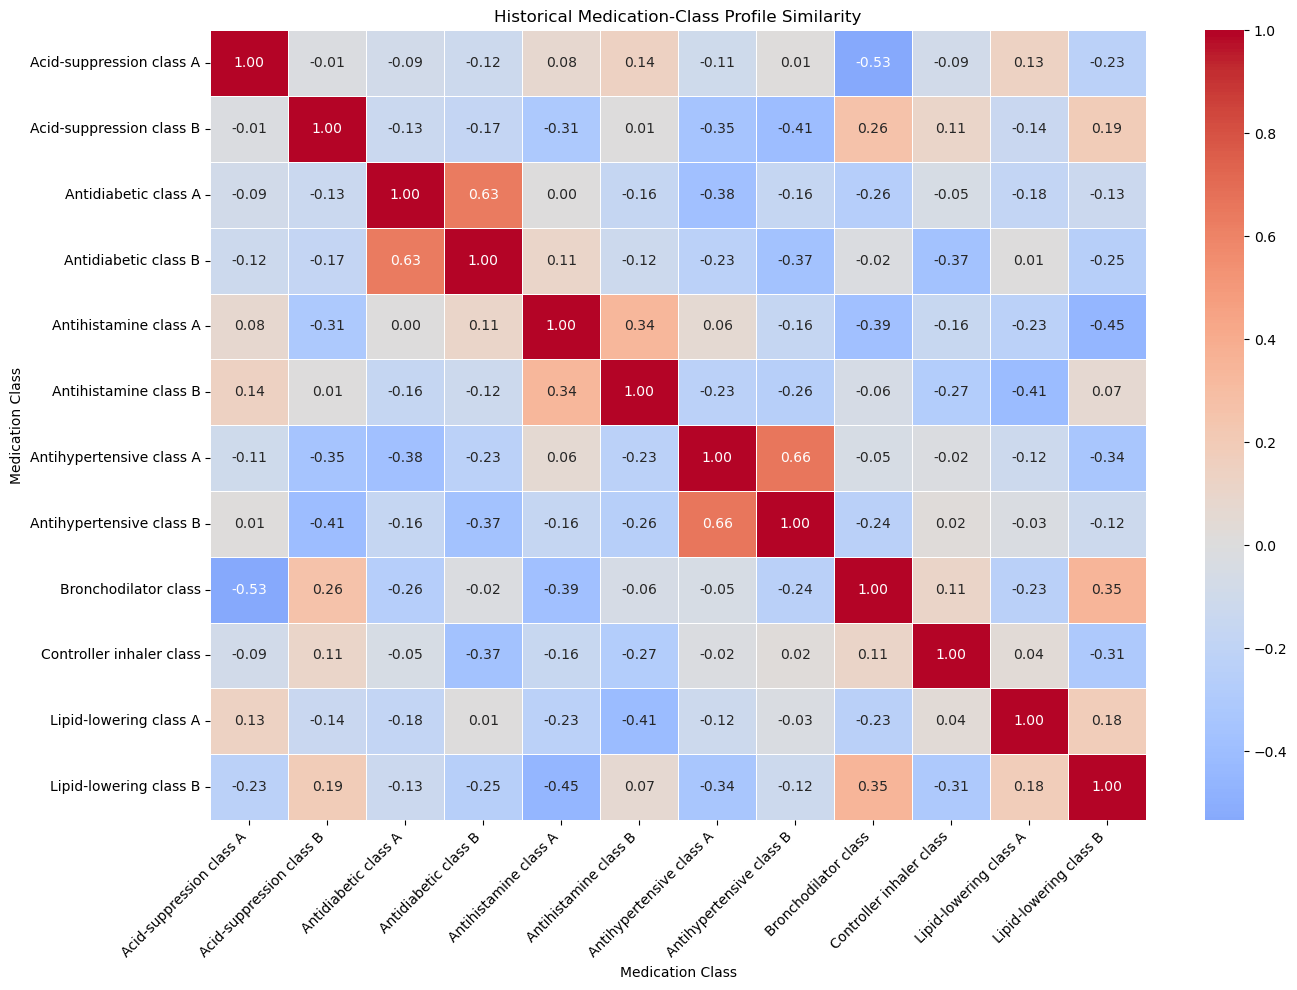

In [24]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    medicine_similarity_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Historical Medication-Class Profile Similarity")
plt.xlabel("Medication Class")
plt.ylabel("Medication Class")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [25]:
def find_similar_medicine_classes(
    medicine_class_name,
    top_n=3
):
    matches = medicine_metadata.index[
        medicine_metadata[
            "historical_medication_class"
        ] == medicine_class_name
    ].tolist()

    if not matches:
        raise ValueError(
            f"Medication class '{medicine_class_name}' was not found."
        )

    medicine_index = matches[0]

    scores = medicine_similarity_matrix[
        medicine_index
    ]

    similar_indices = np.argsort(scores)[::-1]

    similar_indices = [
        index for index in similar_indices
        if index != medicine_index
    ][:top_n]

    result = medicine_metadata.iloc[
        similar_indices
    ].copy()

    result["profile_similarity"] = [
        scores[index]
        for index in similar_indices
    ]

    return result.reset_index(drop=True)

In [26]:
find_similar_medicine_classes(
    "Antidiabetic class A",
    top_n=3
)

,medicine_class_id,historical_medication_class,profile_similarity
0,MEDC-004,Antidiabetic class B,0.628710
1,MEDC-005,Antihistamine class A,0.000809
2,MEDC-010,Controller inhaler class,-0.050267


In [27]:
output_file = "medicine_profile_representation.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    medicine_profile.to_excel(
        writer,
        sheet_name="Medicine_Profiles",
        index=False
    )

    medicine_vector_df.to_excel(
        writer,
        sheet_name="Medicine_Vectors",
        index=False
    )

    reduced_medicine_profile_df.to_excel(
        writer,
        sheet_name="Reduced_Vectors",
        index=False
    )

    medicine_similarity_df.to_excel(
        writer,
        sheet_name="Similarity_Matrix"
    )

    medicine_profile_quality.to_excel(
        writer,
        sheet_name="Profile_Quality",
        index=False
    )

print("Saved:", output_file)

Saved: medicine_profile_representation.xlsx


In [28]:
joblib.dump(
    medicine_scaler,
    "medicine_profile_scaler.pkl"
)

joblib.dump(
    medicine_pca,
    "medicine_profile_pca.pkl"
)

print("Medicine profile scaler and PCA model saved.")

Medicine profile scaler and PCA model saved.
